In [1]:
import sys
import numpy as np
import torch 
print (torch.cuda.get_device_name())

# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
NumExpr defaulting to 8 threads.


### Settings and Load data

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
# mouse brain MLCB version 
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

# human muscle 
#input_files_folder = '/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle_Yes/'

# mouse muscle 
#input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/"

#cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
# 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
# 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']

#ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes") #celltypes=cell_types

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  16206
Number of junctions after removing singletons:  16203
The number of unique cell types in the data is:  9
The number of unique cells in the data is:  7856
The number of unique junctions in the data is:  16204
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
The number of junctions in the data is:  15942
The number of cells in the data is:  7856
The number of cell types in the data is:  9


In [5]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7856
7856


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [6]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [7]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [8]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [9]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [10]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [11]:
cluster_counts

<7856x15942 sparse matrix of type '<class 'numpy.int64'>'
	with 10597973 stored elements in COOrdinate format>

In [12]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.9153789267535754


## Evaluate performance on imputation/masking task

In [ ]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

In [ ]:
#1. get masked matrix using intron cluster counts for this mouse brain data 

# same masking percentage for all three matrices but generating three different masks
masking_percs = [0.05, 0.1, 0.1001, 0.2]
masks_list = []
seeds_used = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
    seeds_used.append(seed)
    # append to masks_list
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

In [ ]:
# Now can run factor model on masked data
Ks = [10, 20, 100, 500]
all_Ks_results = {}
# Seeds used for masking 
seeds_used 

# define list of seeds for training factor model 
seeds = [42, 43, 44]

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, K=k, seeds=seeds,loss_plot=False, num_epochs=70, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

In [ ]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, K, perc_mask, J, nepoch])

In [ ]:
import pandas as pd 
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "K",  "perc_masked" , "J", "num_epochs"])
# save to csv
masked_perf_df.to_csv("masked_perf_df.csv")

#### Make plots 

In [ ]:
masked_perf_df.head()

In [ ]:
# make new column combining seed and perc_masked
masked_perf_df['seed_perc_masked'] = masked_perf_df['seed'].astype(str) + "_" + masked_perf_df['perc_masked'].astype(str)
masked_perf_df.head()

# there should be 2 seperate seed_perc_masked values for each K because there were two seperate masks used 
masked_perf_df['seed_perc_masked'].value_counts()

In [ ]:
masked_perf_df[masked_perf_df["seed"] == 42].l1.unique()

In [ ]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())


#### Variation in performance mainly stems from which seed used for training model 

In [ ]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

In [ ]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="l2", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L2")
ax.set_title("L2 loss on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

In [ ]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

In [ ]:
# get median l1 error and pearson r for each K and across all masking percentages
median_l1 = masked_perf_df.groupby(["K"])["l1"].median()
median_r = masked_perf_df.groupby(["K"])["r"].median()
median_l2 = masked_perf_df.groupby(["K"])["l2"].median()
median_rmse = masked_perf_df.groupby(["K"])["rmse"].median()

# find K that gives the lowest l1 error and print it
min_l1 = median_l1.idxmin()
print("The K that gives the lowest median l1 error is: " + str(min_l1))

# find K that gives the lowest l2 error and print it
min_l2 = median_l2.idxmin()
print("The K that gives the lowest median l2 error is: " + str(min_l2))

# find K that gives the highest r and print it
max_r = median_r.idxmax()
print("The K that gives the highest median r is: " + str(max_r))

# find K that gives the lowest rmse and print it
min_rmse = median_rmse.idxmin()
print("The K that gives the lowest median rmse is: " + str(min_rmse))

## Run full factor model! 

In [15]:
reload(factor_model)


2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 1719
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model


/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py:146: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(hyperparam, dtype=torch.float32)


Epoch 0, Elbo loss: 265615571.0195664
Epoch 20, Elbo loss: 102327207.18919006
Epoch 40, Elbo loss: 72182472.99454325
Epoch 60, Elbo loss: 65980521.17330196
Epoch 80, Elbo loss: 63868640.90089668
Epoch 100, Elbo loss: 62755261.51885505
Epoch 120, Elbo loss: 62045364.684384234
Epoch 140, Elbo loss: 61563250.556549795
Epoch 160, Elbo loss: 61201453.75110589
Epoch 180, Elbo loss: 60925642.08755399
Epoch 200, Elbo loss: 60706196.84160941
Epoch 220, Elbo loss: 60526449.97514704
Epoch 240, Elbo loss: 60379090.47988744
Epoch 260, Elbo loss: 60249512.03913733
Epoch 280, Elbo loss: 60139011.53353474
Epoch 300, Elbo loss: 60043422.89040843
Epoch 320, Elbo loss: 59964664.062236115
Epoch 340, Elbo loss: 59891049.00914951
Epoch 360, Elbo loss: 59826368.84306072
Epoch 380, Elbo loss: 59762553.36796195
Epoch 400, Elbo loss: 59710446.5998813
Epoch 420, Elbo loss: 59661024.22167046
Epoch 440, Elbo loss: 59622009.79120724
Epoch 460, Elbo loss: 59584221.6121161
Epoch 480, Elbo loss: 59550974.80145675
Epoc

Elbo loss: 59131471.37770058


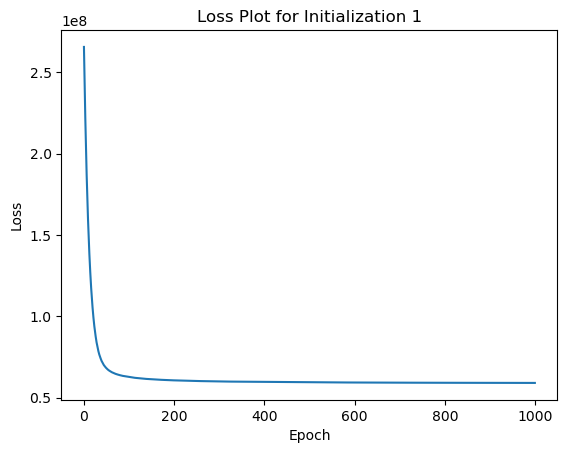

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [16]:
best_K = 10 
K = best_K
# make input conc infinity first 
input_conc = torch.tensor(np.inf, **float_type)
#input_conc = 5
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=1, use_global_prior=True, input_conc=input_conc, K=K, lr=0.1, loss_plot=True, num_epochs=250, save_to_file = False)

In [17]:
# fetch optimized guide parameters, each (loc, scale) pair parameterizes a single normal distribution in the guide corresponding to a different unobserved pyro.sample statement in the model
for name, value in pyro.get_param_store().items():
    print(name, pyro.param(name))

NameError: name 'pyro' is not defined

In [19]:
latent_vars

{'_AutoDiagonalNormal_latent': array([ 1.1399722 ,  0.15602216,  0.38798615, ..., -0.9895232 ,
        -9.638591  , 10.204593  ], dtype=float32),
 'data': array([   0,    1,    2, ..., 7853, 7854, 7855]),
 'mu': array(0.7576745, dtype=float32),
 'a': array([1.1688521 , 1.4740094 , 0.6993109 , ..., 0.17213912, 0.28691804,
        0.1389852 ], dtype=float32),
 'b': array([1.853098  , 2.1734304 , 0.59248966, ..., 0.7338322 , 1.5943605 ,
        0.1231309 ], dtype=float32),
 'psi': array([[4.7393620e-01, 4.3954217e-01, 4.7351798e-01, ..., 8.3378551e-04,
         8.1870556e-01, 2.7208665e-04],
        [4.9393111e-01, 5.3599107e-01, 3.9211485e-01, ..., 1.6752660e-03,
         1.8328489e-01, 1.0239101e-01],
        [4.0086272e-01, 4.8190317e-01, 6.8313485e-01, ..., 1.5781801e-03,
         2.8107159e-02, 9.9832410e-01],
        ...,
        [9.6292138e-01, 7.5421780e-02, 4.3893307e-02, ..., 3.4446749e-03,
         5.1596703e-04, 9.9999678e-01],
        [5.2525401e-01, 4.4502968e-01, 6.2066531e

In [18]:
# extract latent variables for just first seed used 
latent_vars = all_results[0]['latent_vars'] 
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k

mu = latent_vars["mu"] 

dir_conc = latent_vars["dir_conc"] # one scaling value 

assign_post = latent_vars["assign"]

psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster

a = latent_vars["a"] 
b = latent_vars["b"] 
print(a)
print(b)

print("The inferred concentration parameter is: " + str(conc))
print("The inferred pi parameter is: " + str(pi))

KeyError: 'conc'

### Evaluate latent variables 

In [ ]:
cell_ids_conversion

In [ ]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
    )
cluster.cax.set_ylabel('Post assignment', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [ ]:
# above heatmap is cluster assignment matrix 
# before heatmap we had one factor contributing to a bunch of cells 
# re-save those heatmaps for global prior and no global prior
# with PCA, you always have choice to center first or not, if not - but centering would have an effect, first PC ends up represnting the mean 
# for every gene, could have a PC where the values are always kind of constant for every cell 
# and the loading for the genes would just be their means... 
# can use a PC to model a mean 
# similarly here could just have a factor to represent the mean

In [ ]:
# print cell type color legend seperately
import matplotlib.pyplot as plt

cell_type_colors
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right')
plt.xlabel("Cell Type")

# let's calculate silhouette score ussing assign_post
ss = silhouette_score(assign_post, cell_types)
# print with K equals K the ss is 
print("The silhouette score for K = " + str(K) + " is: " + str(ss))

# get davies bouldin score
from sklearn.metrics import davies_bouldin_score
dbs = davies_bouldin_score(assign_post, cell_types)
print("The Davies Bouldin score for K = " + str(K) + " is: " + str(dbs))

In [ ]:
# make UMAP using average assign_post across seeds and color points by cell_type 
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [ ]:
# plot UMAP 
# add whitegrid 
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8,
    cmap="Spectral",
)
# xlab 
plt.xlabel("UMAP 1")
# ylab
plt.ylabel("UMAP 2")

In [ ]:
# plot cell_type_colors legend
sns.palplot(color_palette)
plt.title("Cell Type Legend")
# add cell type names to legend
plt.xticks(np.arange(len(unique_cell_types)), unique_cell_types, rotation=45, ha='right', size=8)

In [ ]:
# now run PCA on assign_post 
pca = PCA(n_components=10)
pca.fit(assign_post)
print(pca.explained_variance_ratio_)

import pandas as pd

pcs = pca.transform(assign_post)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
cell_types_pcs = cell_ids_conversion["cell_type"]

sns.set_style("whitegrid")
sns.set_context("paper")

plt.figure(figsize=(6, 6))
plt.scatter(
    pcs_df["PC1"],
    pcs_df["PC2"],
    c=[cell_type_colors[cell_type] for cell_type in cell_types],
    s=0.8, alpha=0.5, 
    cmap="Spectral",
)
# xlab 
plt.xlabel("PC 1")
# ylab
plt.ylabel("PC 2")

In [ ]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = assign_post[cell_type_indices].mean(axis=0)

# make a dataframe
cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df

In [ ]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 10},
    yticklabels=True,
    figsize=(14, 6),
    center=0,
    cbar_kws={'label': 'Factor contribution'} 
    )
# increase font of everything 
cluster.ax_heatmap.tick_params(labelsize=10)
cluster.ax_heatmap.set_xlabel('Factor', size=10)
cluster.ax_heatmap.set_ylabel('Cell Type', size=10)
cluster.cax.set_ylabel('Factor contribution', size=10)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [ ]:
# what if we prune the factors that are very lowly expressed, can we still see clear seperation of cell types?

# look at pi 
conc

In [ ]:
pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
pi

In [ ]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=5)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")
